The dataset used in this analysis is from the UW Bothell NeuroRehab Ecosystem team. It is filtered and processed EEG (brain signal) data which was taken either during rest or while the subject was performing a specified hand gesture. Each channel corresponds to a different electrode location as shown in the figure below. The target for the first model is binary classification between rest and movement and performs much better than the data with all actions separated out. This multiclass data is defined by an action ID as follows:
<ul type="none">
  <li>1: rest</li>
  <li>2: wave out</li>
  <li>3: wave in</li>
  <li>4: fist</li>
  <li>5: finger spread</li>
  <li>6: double finger tap</li>
</ul>

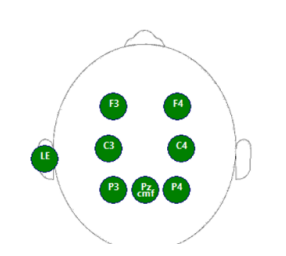

#Setup

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns                       #visualisation
import matplotlib.pyplot as plt             #visualisation
%matplotlib inline
sns.set(color_codes=True)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, FastICA
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/erp_clean.csv")

#Exploratory Data Analysis

##Data Cleanup

In [ ]:
df.head()

,event_time,le,f4,c4,p4,p3,c3,f3,position,action_name,action_id,game_id,subject_id,session_id,id
0,-70.000000,-3.165593,-0.575339,-1.380342,-1.473592,-2.789842,-1.896901,-2.317876,2.0,Fist,4,1,3,4,1
1,-66.666667,-2.092327,0.457063,-0.740726,-1.282948,-2.814202,-1.611334,-1.702711,2.0,Fist,4,1,3,4,2
2,-63.333333,-0.948923,1.434529,-0.129311,-1.075050,-2.703964,-1.277875,-1.014324,2.0,Fist,4,1,3,4,3
3,-60.000000,0.192261,2.292007,0.407074,-0.869605,-2.468733,-0.923387,-0.304072,2.0,Fist,4,1,3,4,4
4,-56.666667,1.261814,2.972695,0.829718,-0.683443,-2.123858,-0.573968,0.376574,2.0,Fist,4,1,3,4,5


In [ ]:
df.tail()

,event_time,le,f4,c4,p4,p3,c3,f3,position,action_name,action_id,game_id,subject_id,session_id,id
55195,580.000000,-5.907023,-7.120665,-6.641901,-2.629813,-3.297823,-6.506506,-7.701248,NaN,Finger Spread,5,2,3,3,63721
55196,583.333333,-5.774918,-7.004617,-6.577874,-2.759031,-4.238666,-6.509705,-7.770901,NaN,Finger Spread,5,2,3,3,63722
55197,586.666667,-5.433866,-6.558536,-6.268172,-2.802073,-4.986532,-6.243668,-7.517718,NaN,Finger Spread,5,2,3,3,63723
55198,590.000000,-4.913059,-5.807175,-5.737217,-2.760212,-5.514883,-5.729518,-6.957863,NaN,Finger Spread,5,2,3,3,63724
55199,593.333333,-4.244904,-4.790868,-5.015668,-2.635180,-5.806758,-4.998118,-6.120490,NaN,Finger Spread,5,2,3,3,63725


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55200 entries, 0 to 55199
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   event_time   55200 non-null  float64
 1   le           55200 non-null  float64
 2   f4           55200 non-null  float64
 3   c4           55200 non-null  float64
 4   p4           55200 non-null  float64
 5   p3           55200 non-null  float64
 6   c3           55200 non-null  float64
 7   f3           55200 non-null  float64
 8   position     18400 non-null  float64
 9   action_name  55200 non-null  object 
 10  action_id    55200 non-null  int64  
 11  game_id      55200 non-null  int64  
 12  subject_id   55200 non-null  int64  
 13  session_id   55200 non-null  int64  
 14  id           55200 non-null  int64  
dtypes: float64(9), int64(5), object(1)
memory usage: 6.3+ MB


In [ ]:
# Drop irrelevant columns
# Only keeping channel data and action_id (target)
df = df.drop(['event_time', 'position', 'action_name', 'game_id', 'subject_id', 'session_id', 'id'], axis=1)
df.head()

,le,f4,c4,p4,p3,c3,f3,action_id
0,-3.165593,-0.575339,-1.380342,-1.473592,-2.789842,-1.896901,-2.317876,4
1,-2.092327,0.457063,-0.740726,-1.282948,-2.814202,-1.611334,-1.702711,4
2,-0.948923,1.434529,-0.129311,-1.075050,-2.703964,-1.277875,-1.014324,4
3,0.192261,2.292007,0.407074,-0.869605,-2.468733,-0.923387,-0.304072,4
4,1.261814,2.972695,0.829718,-0.683443,-2.123858,-0.573968,0.376574,4


In [ ]:
df = df.rename(columns={"action_id": "target"})
df.head()

,le,f4,c4,p4,p3,c3,f3,target
0,-3.165593,-0.575339,-1.380342,-1.473592,-2.789842,-1.896901,-2.317876,4
1,-2.092327,0.457063,-0.740726,-1.282948,-2.814202,-1.611334,-1.702711,4
2,-0.948923,1.434529,-0.129311,-1.075050,-2.703964,-1.277875,-1.014324,4
3,0.192261,2.292007,0.407074,-0.869605,-2.468733,-0.923387,-0.304072,4
4,1.261814,2.972695,0.829718,-0.683443,-2.123858,-0.573968,0.376574,4


In [ ]:
df['target'] = df['target'] - 1 # Start at 0 instead of 1
df.head()

,le,f4,c4,p4,p3,c3,f3,target
0,-3.165593,-0.575339,-1.380342,-1.473592,-2.789842,-1.896901,-2.317876,3
1,-2.092327,0.457063,-0.740726,-1.282948,-2.814202,-1.611334,-1.702711,3
2,-0.948923,1.434529,-0.129311,-1.075050,-2.703964,-1.277875,-1.014324,3
3,0.192261,2.292007,0.407074,-0.869605,-2.468733,-0.923387,-0.304072,3
4,1.261814,2.972695,0.829718,-0.683443,-2.123858,-0.573968,0.376574,3


In [ ]:
df.shape

(55200, 8)

In [ ]:
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)

number of duplicate rows:  (0, 8)


There are no duplicate rows to clean up

In [ ]:
print(df.isnull().sum())

le        0
f4        0
c4        0
p4        0
p3        0
c3        0
f3        0
target    0
dtype: int64


There are no null values to clean up

In [ ]:
df.describe()

,le,f4,c4,p4,p3,c3,f3,target
count,55200.000000,55200.000000,55200.000000,55200.000000,55200.000000,55200.000000,55200.000000,55200.000000
mean,0.001972,-0.006900,-0.011159,0.031250,-0.011688,0.015423,-0.017015,2.833333
std,4.340644,11.419328,4.591318,4.324659,3.178405,4.669732,7.252220,1.674994
min,-48.018250,-491.558533,-225.110372,-101.359055,-54.520162,-56.817174,-206.383179,0.000000
25%,-2.450620,-2.576340,-2.065225,-1.494004,-1.637827,-2.077347,-2.535832,1.750000
50%,-0.011437,0.016778,-0.000206,-0.004506,0.010632,0.007064,0.017515,3.000000
75%,2.442478,2.561711,2.059538,1.504297,1.640861,2.116068,2.571251,4.000000
max,56.058024,424.452606,58.299123,212.993327,57.780991,221.041646,165.261002,5.000000


##Plot: Fist Action
Plot of the first 200 rows of the dataframe, corresponding to the fist action

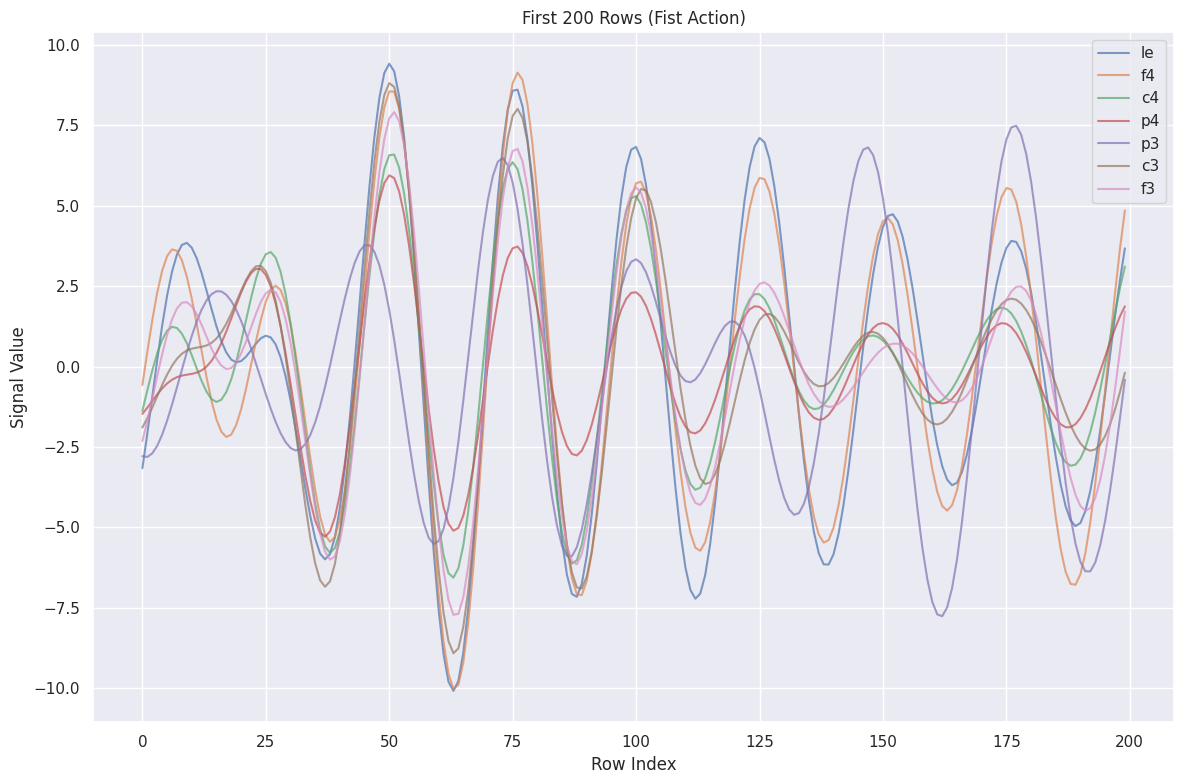

In [ ]:
rows = 200
subset = df.iloc[:rows]

plt.figure(figsize=(12,8))

for i, column in enumerate(subset.columns[:7]):
  plt.plot(subset.index, subset[column], label=column, alpha=0.7)

plt.title('First 200 Rows (Fist Action)')
plt.xlabel('Row Index')
plt.ylabel('Signal Value')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


##Detecting Outliers
While boxplots were used to detect outliers, outliers were not initially removed because in visualizations such as pairplots, separations between gestures were more visible with outliers present and thus it was decided that the outliers were useful for classification. This intuition proved to be correct, as can be observed in LSTM Model Attempt #3, where I try removing outliers. This resulted in a reduction of accuracy by approximately half.

<Axes: xlabel='le'>

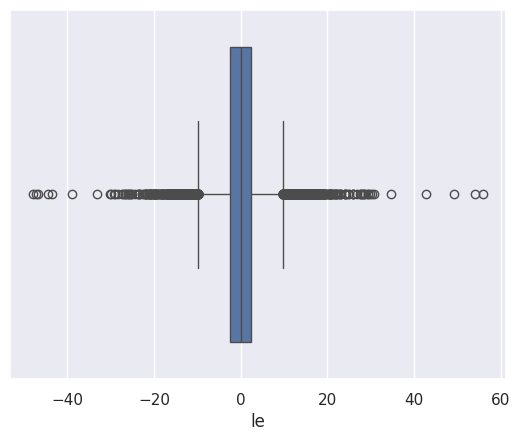

In [ ]:
sns.boxplot(x=df['le'])

<Axes: xlabel='f4'>

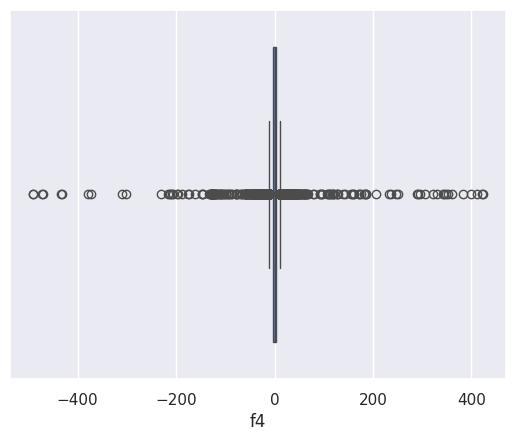

In [ ]:
sns.boxplot(x=df['f4'])

<Axes: xlabel='c4'>

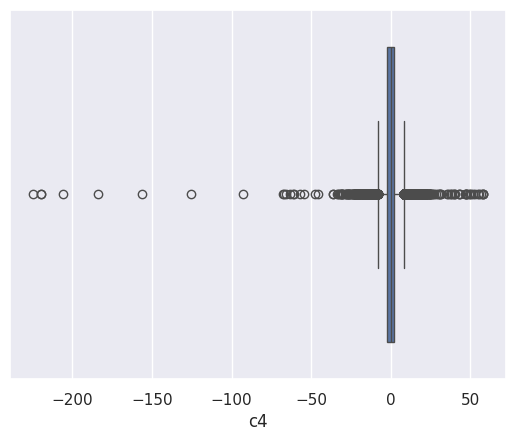

In [ ]:
sns.boxplot(x=df['c4'])

<Axes: xlabel='p4'>

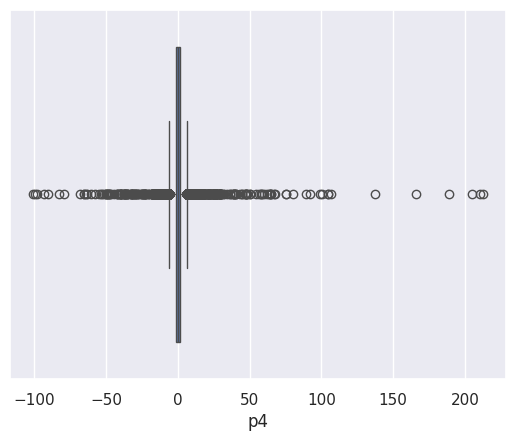

In [ ]:
sns.boxplot(x=df['p4'])

<Axes: xlabel='p3'>

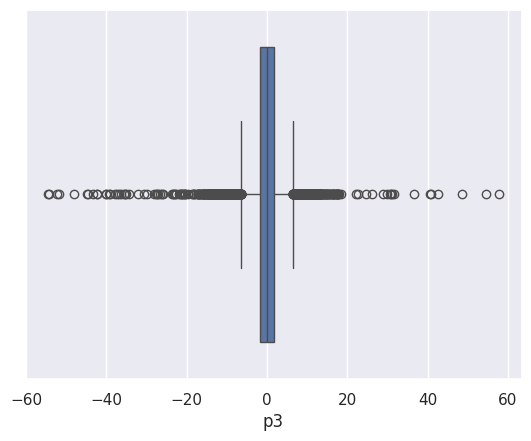

In [ ]:
sns.boxplot(x=df['p3'])

<Axes: xlabel='c3'>

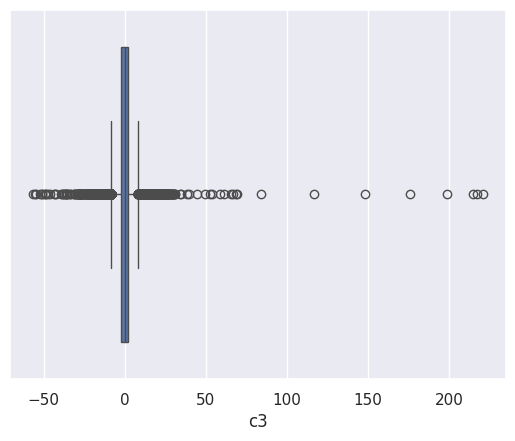

In [ ]:
sns.boxplot(x=df['c3'])

<Axes: xlabel='f3'>

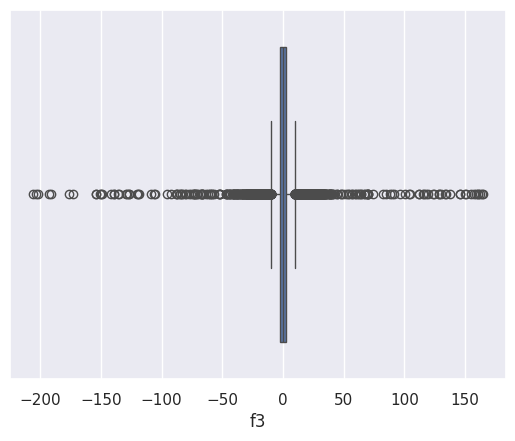

In [ ]:
sns.boxplot(x=df['f3'])

##Histogram
Only one histogram is included here because the rest look approximately the same (approximately a normal distribution), just with different values on the x-axis.

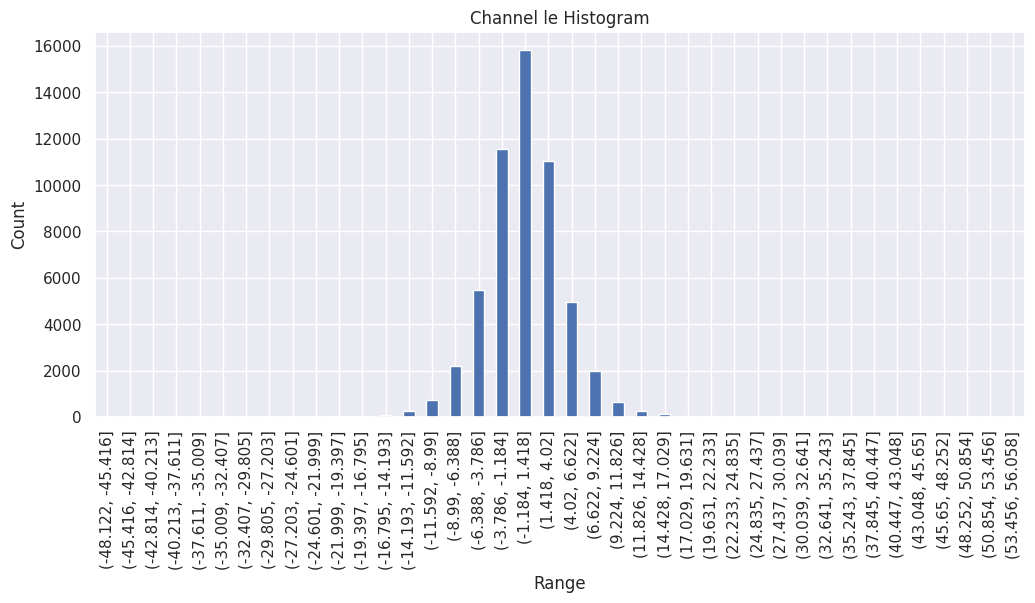

In [ ]:
le_bins = pd.cut(df['le'], bins=40).value_counts().sort_index()
le_bins.plot(kind='bar', figsize=(12, 5))

plt.title("Channel le Histogram")
plt.ylabel('Count')
plt.xlabel('Range');

##Heat Maps
Most channels are somewhat positively correlated, with f4 and f3 (frontal lobes) showing large positive correlation. However, channels have very low linear correlation with the target.

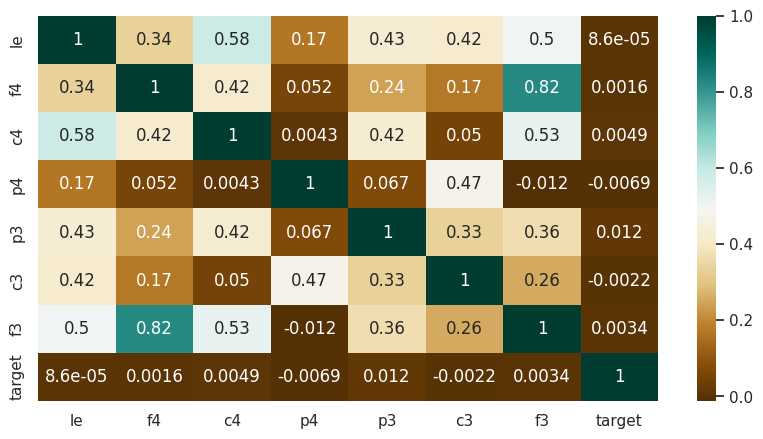

              le        f4        c4        p4        p3        c3        f3  \
le      1.000000  0.335952  0.584121  0.168313  0.425984  0.418754  0.502194   
f4      0.335952  1.000000  0.417955  0.051603  0.244264  0.173784  0.823539   
c4      0.584121  0.417955  1.000000  0.004299  0.419279  0.049709  0.527242   
p4      0.168313  0.051603  0.004299  1.000000  0.067374  0.472608 -0.011813   
p3      0.425984  0.244264  0.419279  0.067374  1.000000  0.334225  0.364156   
c3      0.418754  0.173784  0.049709  0.472608  0.334225  1.000000  0.255850   
f3      0.502194  0.823539  0.527242 -0.011813  0.364156  0.255850  1.000000   
target  0.000086  0.001640  0.004885 -0.006872  0.011911 -0.002192  0.003355   

          target  
le      0.000086  
f4      0.001640  
c4      0.004885  
p4     -0.006872  
p3      0.011911  
c3     -0.002192  
f3      0.003355  
target  1.000000  


In [ ]:
plt.figure(figsize=(10,5))
c = df.corr()
sns.heatmap(c, cmap="BrBG", annot=True)
plt.show()
print(c)

##Pairplots

Each color represents a different gesture. There are clear patterns distinguishing the different classes.

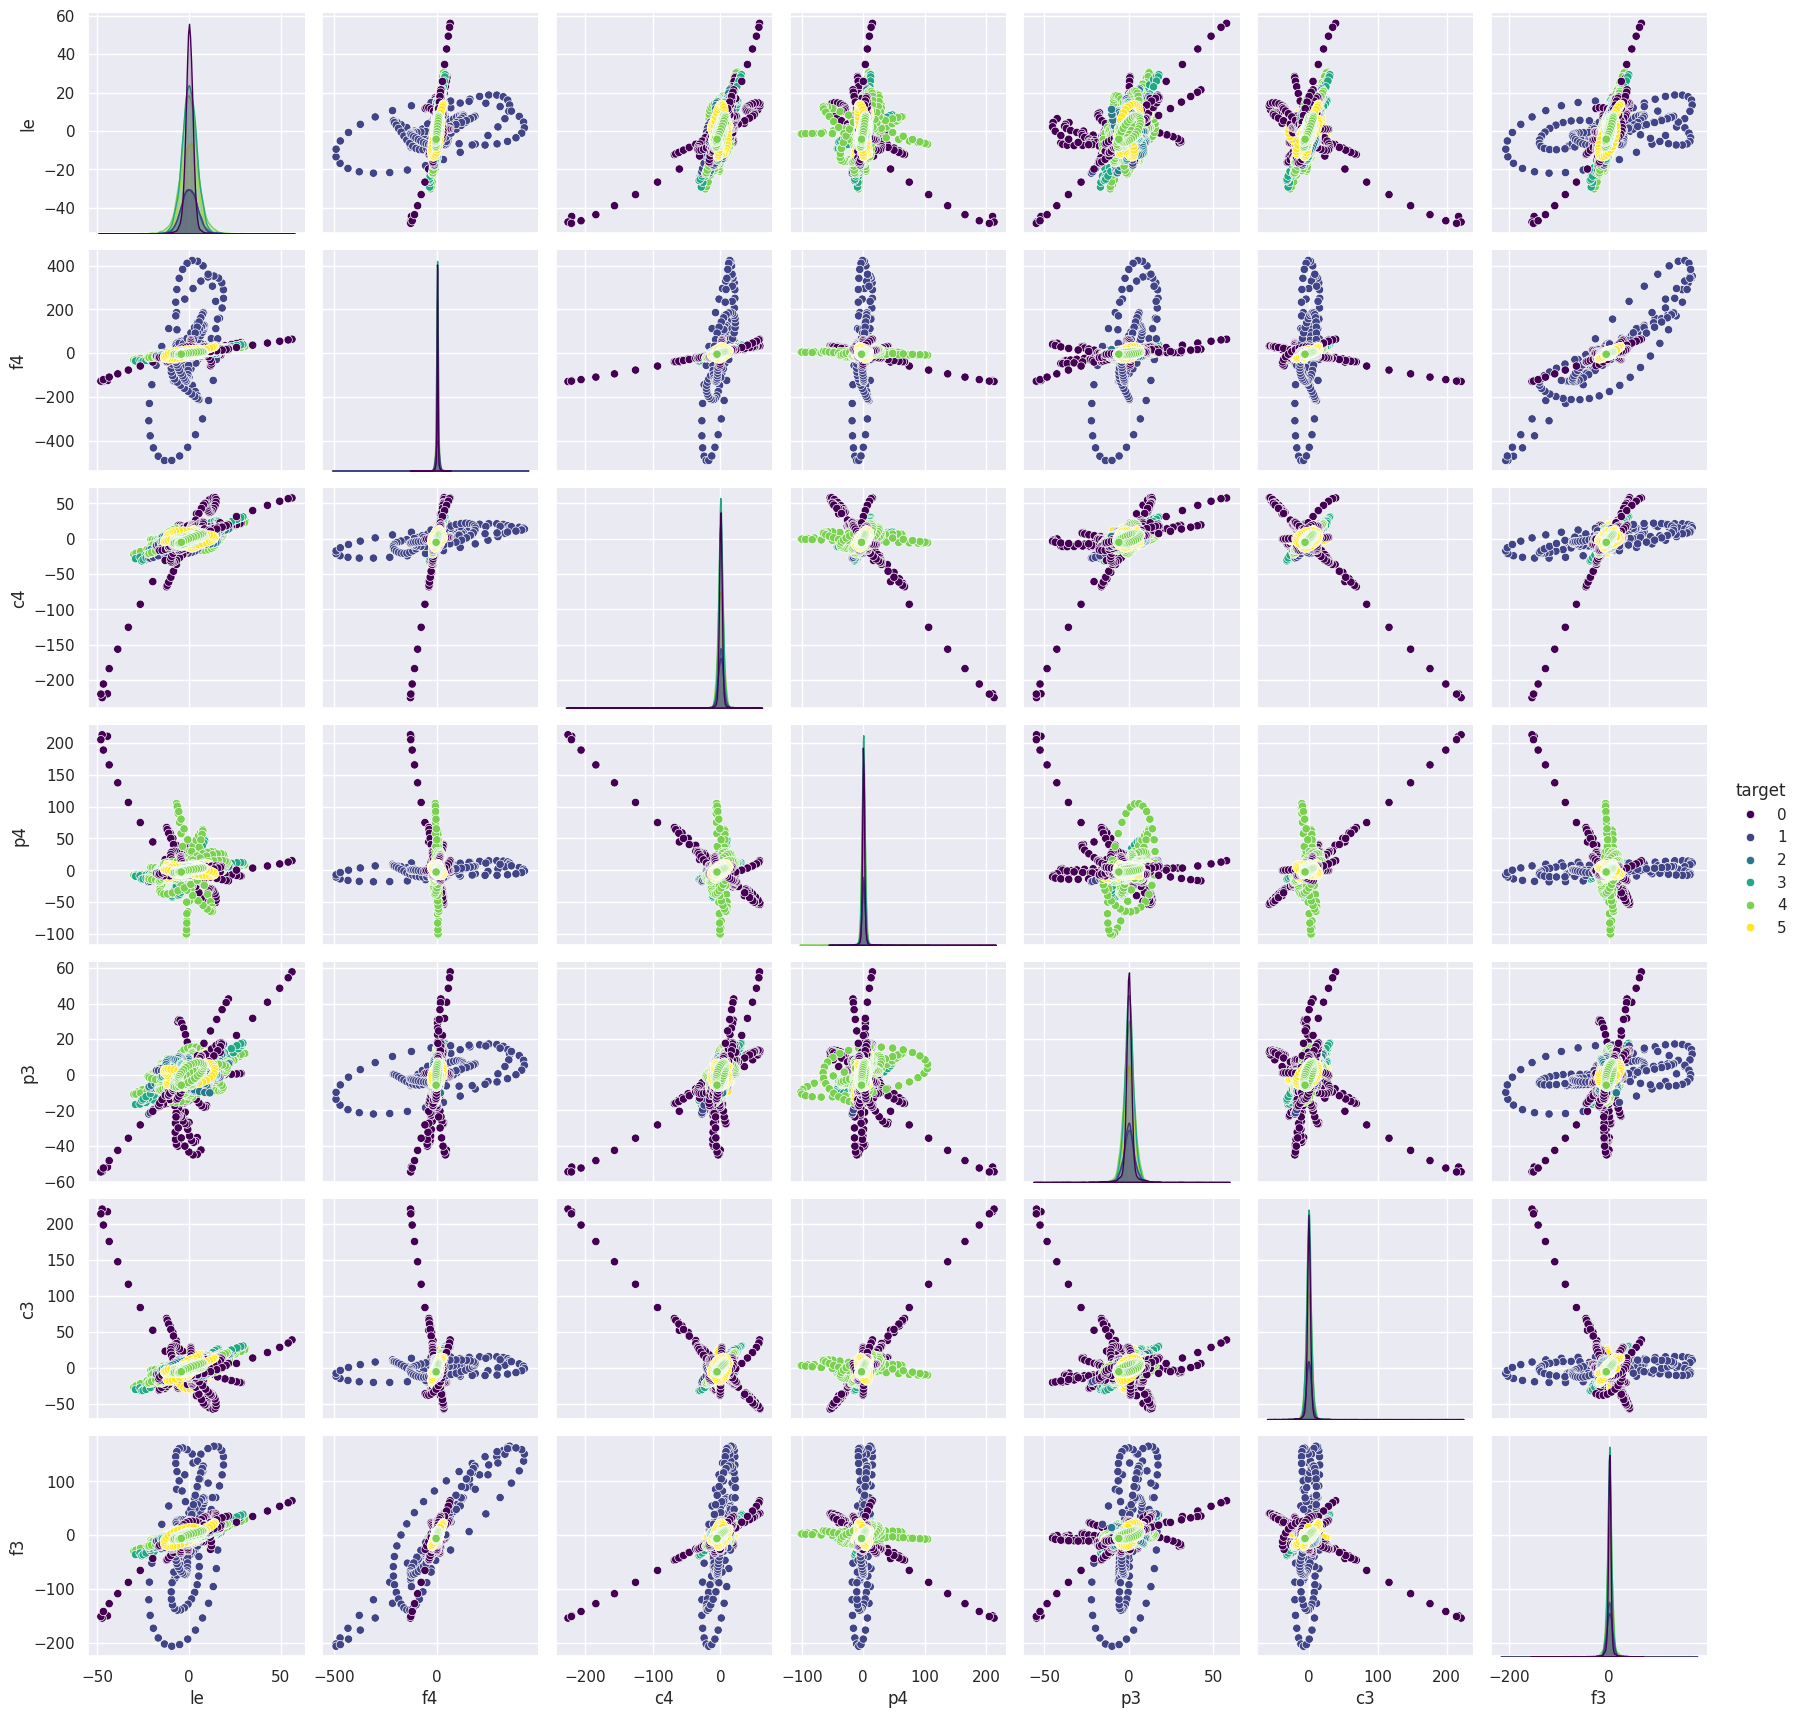

In [ ]:
sns.pairplot(df, hue='target', palette='viridis')

#LSTM Model: Binary Classification
This section only classifies between rest and movement.

While results for binary classification appear to be great, one must take into account that the data is very skewed. There are only 8 instances of rest out of 56 test observations. Thus if the model guesses movement every single time, it would achieve 86% accuracy. It does perform much better than this at a cross-validation average of 99% accuracy, and has decent precision, recall, and f1-score for rest, indicating that it did not merely learn to guess movement every single time and was actually able to distinguish between rest and movement.

In [ ]:
# Map multi-class labels to binary labels
rest_labels = [0]  # Define which label(s) correspond to "Rest"
df['binary_target'] = df['target'].apply(lambda x: 0 if x in rest_labels else 1)
df_binary = df.drop('target', axis=1)

def create_non_overlapping_windows(df, window_size, target_col='target'):
    features = df.drop(columns=[target_col]).values  # Drop target column for features
    labels = df[target_col].values                  # Extract target column

    # Ensure data is divisible by window_size
    num_windows = len(df) // window_size
    truncated_length = num_windows * window_size
    features = features[:truncated_length]
    labels = labels[:truncated_length]

    # Reshape into windows
    X = features.reshape(num_windows, window_size, -1)
    y = labels[::window_size]  # Take the first label in each window (since labels are constant)

    return X, y

# Create windows with binary labels
WINDOW_LENGTH = 200
X, y = create_non_overlapping_windows(df_binary, WINDOW_LENGTH, target_col='binary_target')

# Shuffle and split data
X_shuffled, y_shuffled = shuffle(X, y, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_shuffled, y_shuffled, test_size=0.2, stratify=y, random_state=42)

In [ ]:
num_channels = 7
num_classes = 6

early_stopping = EarlyStopping(patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_lstm_model.keras', save_best_only=True)

In [ ]:
# Binary classification model
model = Sequential([
    LSTM(64, input_shape=(WINDOW_LENGTH, num_channels), return_sequences=True),
    Dropout(0.3),
    LSTM(32, return_sequences=False),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Single neuron with sigmoid activation
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history_binary = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping, model_checkpoint]
)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - accuracy: 0.5307 - loss: 0.6768
Epoch 2/30
1/7 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - accuracy: 0.8125 - loss: 0.5526

/usr/local/lib/python3.10/dist-packages/keras/src/callbacks/early_stopping.py:155: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.10/dist-packages/keras/src/callbacks/model_checkpoint.py:206: UserWarning: Can save best model only with val_loss available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.7972 - loss: 0.5369
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - accuracy: 0.8562 - loss: 0.4390
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.8364 - loss: 0.4087
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.8272 - loss: 0.3966
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 257ms/step - accuracy: 0.8198 - loss: 0.3777
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 267ms/step - accuracy: 0.8602 - loss: 0.3501
Epoch 8/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 163ms/step - accuracy: 0.8395 - loss: 0.3367
Epoch 9/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.8735 - loss: 0.2578
Epoch 10/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step - accuracy: 0.9387 - loss: 0.1757
Epoch 11/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - accuracy: 0.9790 - loss: 0.1084
Epoch 12/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - accuracy: 0.9691 - loss: 0.1176
Epoch 13/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.9775 - loss: 0.0919

##Evaluations

In [ ]:
from sklearn import metrics

def print_evaluate(true, predicted):
    mae = metrics.mean_absolute_error(true, predicted)
    mse = metrics.mean_squared_error(true, predicted)
    rmse = np.sqrt(metrics.mean_squared_error(true, predicted))
    r2_square = metrics.r2_score(true, predicted)
    print('MAE:', mae)
    print('MSE:', mse)
    print('RMSE:', rmse)
    print('R2 Square', r2_square)
    print('__________________________________')

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.9435 - loss: 0.1591
Test Loss: 0.13765746355056763, Test Accuracy: 0.9464285969734192
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 372ms/step
Classification Report:
              precision    recall  f1-score   support

           0      0.778     0.875     0.824         8
           1      0.979     0.958     0.968        48

    accuracy                          0.946        56
   macro avg      0.878     0.917     0.896        56
weighted avg      0.950     0.946     0.948        56



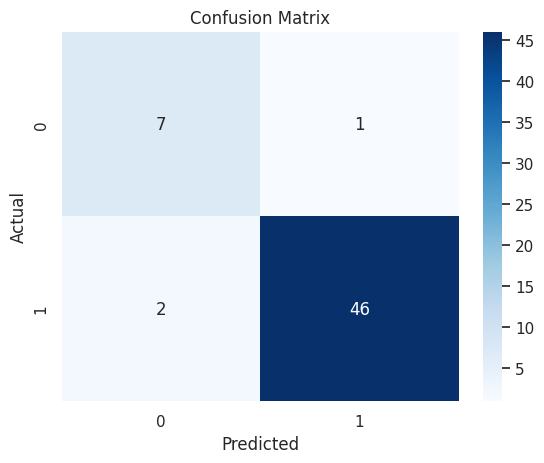

In [ ]:
# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

# Make predictions
y_pred_probs = model.predict(X_test)  # Probabilities
y_pred = (y_pred_probs > 0.5).astype(int)  # Convert probabilities to binary predictions

# Classification report
from sklearn.metrics import classification_report, confusion_matrix
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=3))

# Confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
print('Test set evaluation:\n_____________________________________')
print_evaluate(y_test, y_pred)

Test set evaluation:
_____________________________________
MAE: 0.05357142857142857
MSE: 0.05357142857142857
RMSE: 0.23145502494313785
R2 Square 0.5625
__________________________________


##K-fold Cross-Validation
Cross-validation was performed on the binary classification to verify the high accuracy obtained. It produced an average accuracy of 99%, indicating that the binary model is robust.

In [ ]:
from sklearn.model_selection import StratifiedKFold

def cross_validate_model(model, X, y):

  skf = StratifiedKFold(n_splits=6)

  # List to store accuracy for each fold
  fold_accuracies = []

  for fold, (train_index, val_index) in enumerate(skf.split(X, y)):
    print(f"Starting Fold {fold + 1}...")

    # Split data into train and validation sets
    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]

    # Train the model
    history = model.fit(
        X_train, y_train,
        epochs=30,
        batch_size=32,
        callbacks=[early_stopping, model_checkpoint],
        verbose=0
    )

    # Evaluate on the validation set
    test_loss, test_accuracy = model.evaluate(X_val, y_val, verbose=0)
    print(f"Fold {fold + 1} - Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

    # Store the accuracy
    fold_accuracies.append(test_accuracy)

  # Calculate and report the average accuracy
  average_accuracy = np.mean(fold_accuracies)
  print(f"\nAverage Test Accuracy across {skf.n_splits} folds: {average_accuracy:.4f}")
  return average_accuracy, fold_accuracies

In [ ]:
average_accuracy, fold_accuracies = cross_validate_model(
    model=model,
    X=X,
    y=y
)

print(f"Average Accuracy: {average_accuracy:.4f}")
print(f"Accuracies for each fold: {fold_accuracies}")

Starting Fold 1...


/usr/local/lib/python3.10/dist-packages/keras/src/callbacks/early_stopping.py:155: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.10/dist-packages/keras/src/callbacks/model_checkpoint.py:206: UserWarning: Can save best model only with val_loss available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)


Fold 1 - Test Loss: 0.028761427849531174, Test Accuracy: 0.97826087474823
Starting Fold 2...
Fold 2 - Test Loss: 0.02620854042470455, Test Accuracy: 0.97826087474823
Starting Fold 3...
Fold 3 - Test Loss: 0.0009767329320311546, Test Accuracy: 1.0
Starting Fold 4...
Fold 4 - Test Loss: 0.00024555905838496983, Test Accuracy: 1.0
Starting Fold 5...
Fold 5 - Test Loss: 0.0001408976677339524, Test Accuracy: 1.0
Starting Fold 6...
Fold 6 - Test Loss: 0.0001254448143299669, Test Accuracy: 1.0

Average Test Accuracy across 6 folds: 0.9928
Average Accuracy: 0.9928
Accuracies for each fold: [0.97826087474823, 0.97826087474823, 1.0, 1.0, 1.0, 1.0]


#LSTM Model: Multiclass, Attempt #1
This first attempt does not use hyperparameter tuning, ICA or PCA and includes all outliers. By f1-score and precision, the model performs well on identifying the rest action, and poorly on all others. The overall accuracy of 0.29 is lower than what Arsheya Raj [1] achieved in his thesis for LSTM (39%). I chose LSTM despite the low accuracies he achieved because he did not perform any hyperparameter optimizations, and in theory LSTM is supposed to perform well on time series data.

In [ ]:
df = df_binary = df.drop('binary_target', axis=1)

X, y = create_non_overlapping_windows(df, WINDOW_LENGTH, target_col='target')

print("Shape of X:", X.shape)  # (num_windows, window_size, num_features)
print("Shape of y:", y.shape)  # (num_windows,)

# Shuffle and split data
X_shuffled, y_shuffled = shuffle(X, y, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_shuffled, y_shuffled, test_size=0.2, stratify=y, random_state=42)

Shape of X: (276, 200, 7)
Shape of y: (276,)


In [ ]:
model = Sequential([
    LSTM(64, input_shape=(WINDOW_LENGTH, num_channels), return_sequences=True),
    Dropout(0.3),
    LSTM(32, return_sequences=False),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 261ms/step - accuracy: 0.1676 - loss: 1.8261
Epoch 2/50


/usr/local/lib/python3.10/dist-packages/keras/src/callbacks/early_stopping.py:155: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.10/dist-packages/keras/src/callbacks/model_checkpoint.py:206: UserWarning: Can save best model only with val_loss available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 265ms/step - accuracy: 0.2763 - loss: 1.7449
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.3404 - loss: 1.7027
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.3827 - loss: 1.6429
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.3562 - loss: 1.6367
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step - accuracy: 0.3592 - loss: 1.6060
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - accuracy: 0.3836 - loss: 1.5540
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - accuracy: 0.4613 - loss: 1.4832
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 0.3847 - loss: 1.5084
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step - accuracy: 0.4760 - loss: 1.3988
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 257ms/step - accuracy: 0.4946 - loss: 1.4024
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 275ms/step - accuracy: 0.5058 - loss: 1.3147
Epoch 13/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step - accuracy: 0.5908 - loss: 1.1954

##Evaluations

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.3869 - loss: 2.8922
Test Loss: 2.8019161224365234, Test Accuracy: 0.3928571343421936


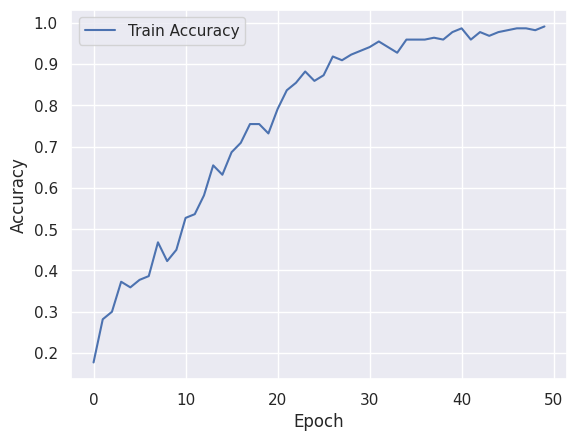

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 471ms/step
Classification Report:
              precision    recall  f1-score   support

           0      0.889     0.889     0.889         9
           1      0.500     0.250     0.333         4
           2      0.000     0.000     0.000         3
           3      0.278     0.357     0.312        14
           4      0.385     0.312     0.345        16
           5      0.231     0.300     0.261        10

    accuracy                          0.393        56
   macro avg      0.380     0.351     0.357        56
weighted avg      0.399     0.393     0.390        56



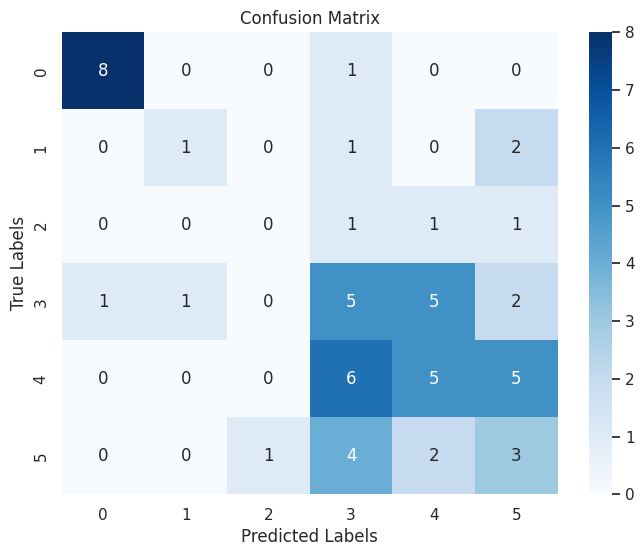

In [ ]:
y_pred = np.argmax(model.predict(X_test), axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [ ]:
print('Test set evaluation:\n_____________________________________')
print_evaluate(y_test, y_pred)

Test set evaluation:
_____________________________________
MAE: 1.0178571428571428
MSE: 2.1964285714285716
RMSE: 1.4820352800890306
R2 Square 0.21117727897388905
__________________________________


#LSTM Model: Multiclass, Attempt #2: Uses ICA and PCA in combination
Using ICA by itself resulted in worse accuracy relative to Attempt #1, as did using ICA and PCA in comination.

In [ ]:
def apply_ica(X, num_components):
    num_windows, window_length, num_channels = X_shuffled.shape
    X_reshaped = X_shuffled.reshape(-1, num_channels)  # Combine windows into a 2D array for ICA
    ica = FastICA(n_components=num_components, random_state=42)
    X_ica = ica.fit_transform(X_reshaped)  # Apply ICA
    return X_ica.reshape(num_windows, window_length, num_components)

def apply_pca(X, num_components):
    num_windows, window_length, num_channels = X_shuffled.shape
    X_reshaped = X_shuffled.reshape(-1, num_channels)  # Combine windows into a 2D array for PCA
    pca = PCA(n_components=num_components)
    X_pca = pca.fit_transform(X_reshaped)  # Apply PCA
    return X_pca.reshape(num_windows, window_length, num_components)

X_ica = apply_ica(X_shuffled, num_channels)

X_pca = apply_pca(X_ica, 5)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2029, stratify=y, random_state=42)

model = Sequential([
    LSTM(64, input_shape=(WINDOW_LENGTH, 5), return_sequences=True),
    Dropout(0.3),
    LSTM(32, return_sequences=False),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')  # num_classes = 6 in your case
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_ica_pca = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 161ms/step - accuracy: 0.2123 - loss: 1.7610
Epoch 2/50


/usr/local/lib/python3.10/dist-packages/keras/src/callbacks/early_stopping.py:155: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.10/dist-packages/keras/src/callbacks/model_checkpoint.py:206: UserWarning: Can save best model only with val_loss available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step - accuracy: 0.2605 - loss: 1.7267
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.3532 - loss: 1.6426
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.3351 - loss: 1.6312
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.4001 - loss: 1.5891
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step - accuracy: 0.3631 - loss: 1.6197
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 257ms/step - accuracy: 0.4154 - loss: 1.5213
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 252ms/step - accuracy: 0.3921 - loss: 1.5531
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 263ms/step - accuracy: 0.4238 - loss: 1.4849
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - accuracy: 0.4188 - loss: 1.5035
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.4587 - loss: 1.3951
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.4812 - loss: 1.3240
Epoch 13/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step - accuracy: 0.4917 - loss: 1.3480

##Evaluations

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.2458 - loss: 3.2118
Test Loss: 3.250915050506592, Test Accuracy: 0.22807016968727112


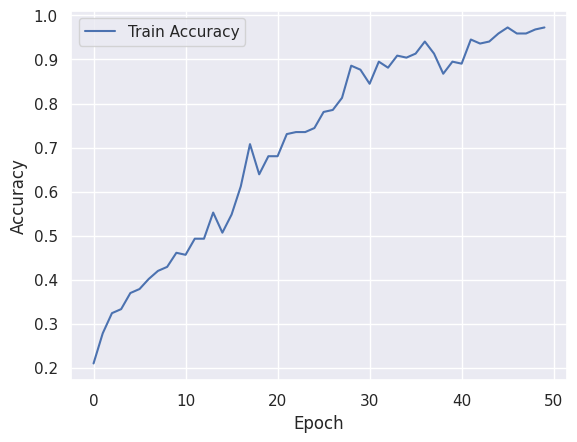

In [ ]:
plt.plot(history_ica_pca.history['accuracy'], label='Train Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 315ms/step
Classification Report:
              precision    recall  f1-score   support

           0      0.167     0.111     0.133         9
           1      1.000     0.200     0.333         5
           2      0.000     0.000     0.000         5
           3      0.190     0.286     0.229        14
           4      0.444     0.286     0.348        14
           5      0.214     0.300     0.250        10

    accuracy                          0.228        57
   macro avg      0.336     0.197     0.216        57
weighted avg      0.308     0.228     0.236        57



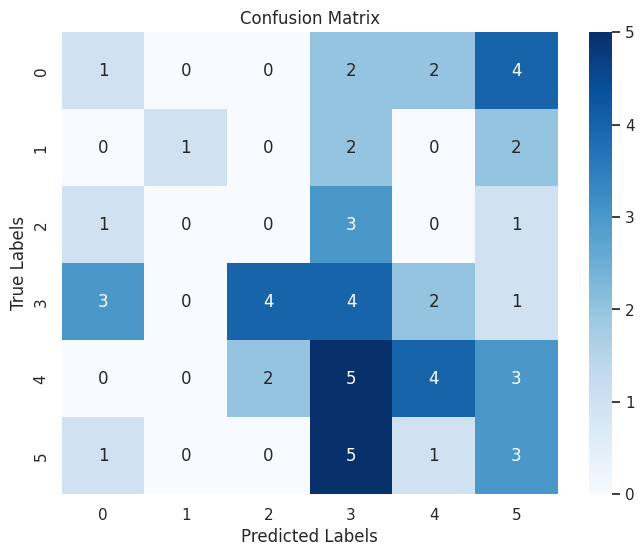

In [ ]:
y_pred = np.argmax(model.predict(X_test), axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [ ]:
print('Test set evaluation:\n_____________________________________')
print_evaluate(y_test, y_pred)

Test set evaluation:
_____________________________________
MAE: 1.736842105263158
MSE: 5.350877192982456
RMSE: 2.313196315270811
R2 Square -0.9197217314487633
__________________________________


#LSTM Model: Multiclass, Attempt #3: Remove Outliers
Removing outliers resulted in worse performance than keeping them, as expected, since separation between classes was more visible in feature scatterplots with outliers than without them.

In [ ]:
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Filter out rows with outliers
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

# List of feature columns
feature_columns = ['le', 'f4', 'c4', 'p4', 'p3', 'c3', 'f3']

# Remove outliers
df_cleaned = remove_outliers(df, feature_columns)

In [ ]:
X_cleaned, y_cleaned = create_non_overlapping_windows(df_cleaned, WINDOW_LENGTH, target_col='target')
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.2, stratify=y_cleaned, random_state=42)


In [ ]:
model = Sequential([
    LSTM(64, input_shape=(WINDOW_LENGTH, num_channels), return_sequences=True),
    Dropout(0.3),
    LSTM(32, return_sequences=False),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_no_outliers = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping, model_checkpoint]
)


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step - accuracy: 0.1492 - loss: 1.8329
Epoch 2/50


/usr/local/lib/python3.10/dist-packages/keras/src/callbacks/early_stopping.py:155: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.10/dist-packages/keras/src/callbacks/model_checkpoint.py:206: UserWarning: Can save best model only with val_loss available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step - accuracy: 0.2195 - loss: 1.7800
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.2560 - loss: 1.7284
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.2725 - loss: 1.6774
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step - accuracy: 0.3150 - loss: 1.6059
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 256ms/step - accuracy: 0.3494 - loss: 1.6292
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 265ms/step - accuracy: 0.3531 - loss: 1.5766
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step - accuracy: 0.3569 - loss: 1.5586
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step - accuracy: 0.4667 - loss: 1.4845
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - accuracy: 0.5104 - loss: 1.4431
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 0.5442 - loss: 1.4108
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.5265 - loss: 1.3813
Epoch 13/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.5673 - loss: 1.3043

##Evaluations

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.2178 - loss: 3.5118 
Test Loss: 3.588665246963501, Test Accuracy: 0.21739129722118378


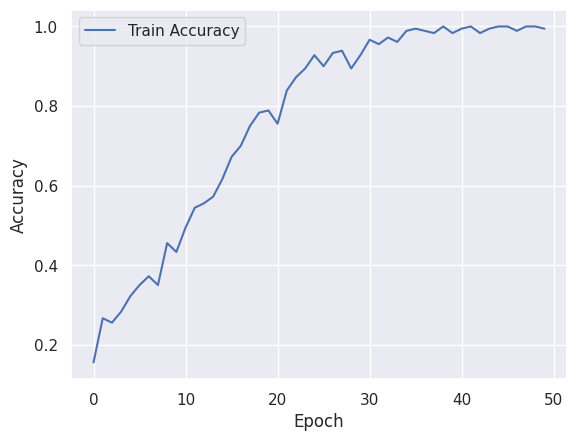

In [ ]:
plt.plot(history_no_outliers.history['accuracy'], label='Train Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 329ms/step
Classification Report:
              precision    recall  f1-score   support

           0      0.500     0.222     0.308         9
           1      0.000     0.000     0.000         4
           2      0.000     0.000     0.000         3
           3      0.176     0.250     0.207        12
           4      0.300     0.273     0.286        11
           5      0.167     0.286     0.211         7

    accuracy                          0.217        46
   macro avg      0.191     0.172     0.168        46
weighted avg      0.241     0.217     0.215        46



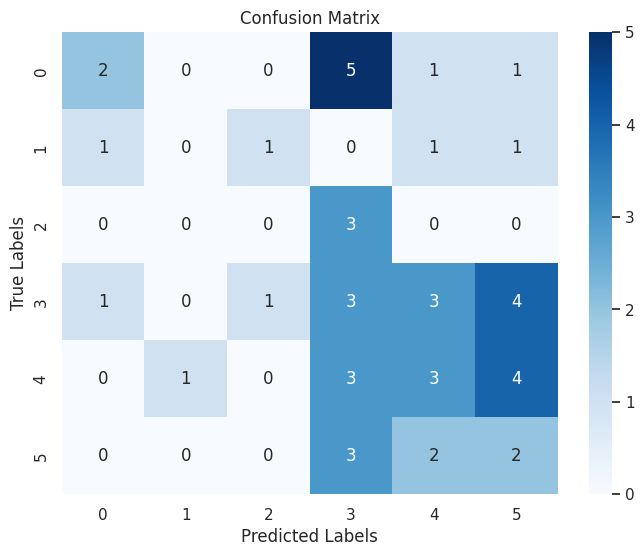

In [ ]:
y_pred = np.argmax(model.predict(X_test), axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

#LSTM Model: Multiclass, Attempt #4: Tune Model Architecture, Part 1
In this section I go back and attempt to improve the multiclass results by varying the model architecture. Accuracy for this new architecture is in the same ballpark as the original.

In [ ]:
model = Sequential([
    LSTM(128, input_shape=(WINDOW_LENGTH, num_channels), return_sequences=True), # 128 instead of 64
    Dropout(0.4), # 0.4 instead of 0.3
    LSTM(64, return_sequences=False), # 64 instead of 32
    Dropout(0.4), # 0.4 instead of 0.3
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_shuffled, y_shuffled, test_size=0.2029, stratify=y, random_state=42)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 341ms/step - accuracy: 0.1676 - loss: 1.8197
Epoch 2/30


/usr/local/lib/python3.10/dist-packages/keras/src/callbacks/early_stopping.py:155: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.10/dist-packages/keras/src/callbacks/model_checkpoint.py:206: UserWarning: Can save best model only with val_loss available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 608ms/step - accuracy: 0.3614 - loss: 1.6259
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 326ms/step - accuracy: 0.3996 - loss: 1.5648
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 344ms/step - accuracy: 0.3931 - loss: 1.5664
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 333ms/step - accuracy: 0.4875 - loss: 1.4434
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 381ms/step - accuracy: 0.5318 - loss: 1.2963
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 330ms/step - accuracy: 0.5673 - loss: 1.1840
Epoch 8/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 327ms/step - accuracy: 0.5404 - loss: 1.1720
Epoch 9/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 328ms/step - accuracy: 0.6462 - loss: 0.9980
Epoch 10/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 332ms/step - accuracy: 0.6718 - loss: 0.9415
Epoch 11/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 615ms/step - accuracy: 0.7132 - loss: 0.8394
Epoch 12/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 332ms/step - accuracy: 0.7775 - loss: 0.7312
Epoch 13/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 333ms/step - accuracy: 0.7851 - loss: 0.6163

##Evaluations

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 231ms/step - accuracy: 0.4499 - loss: 2.3608
Test Loss: 2.3186492919921875, Test Accuracy: 0.45614033937454224


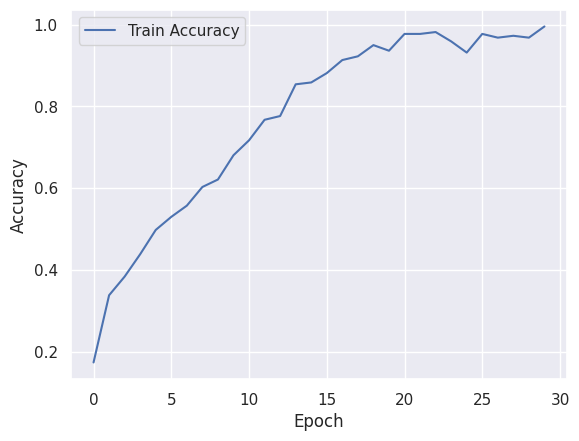

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 377ms/step
Classification Report:
              precision    recall  f1-score   support

           0      0.900     1.000     0.947         9
           1      0.200     0.250     0.222         4
           2      0.333     0.333     0.333         3
           3      0.333     0.286     0.308        14
           4      0.357     0.312     0.333        16
           5      0.462     0.545     0.500        11

    accuracy                          0.456        57
   macro avg      0.431     0.455     0.441        57
weighted avg      0.445     0.456     0.448        57



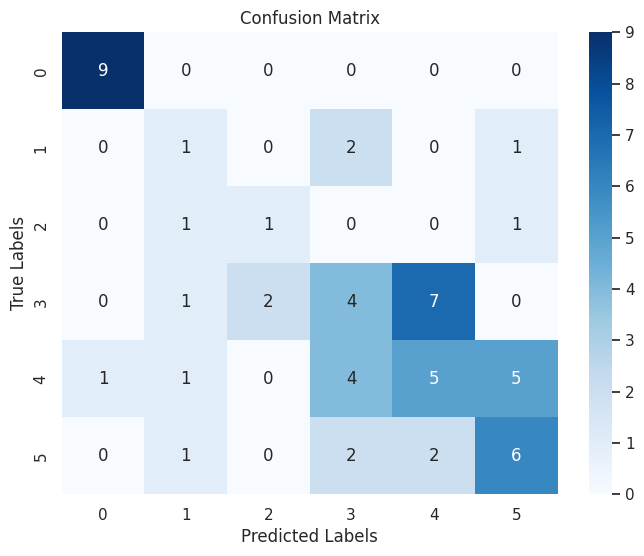

In [ ]:
y_pred = np.argmax(model.predict(X_test), axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [ ]:
print('Test set evaluation:\n_____________________________________')
print_evaluate(y_test, y_pred)

Test set evaluation:
_____________________________________
MAE: 0.8596491228070176
MSE: 1.8771929824561404
RMSE: 1.3701069237311885
R2 Square 0.33125000000000004
__________________________________


#LSTM Model: Multiclass, Attempt #5: Tune Model Architecture, Part 2
This model architecture assumes that previous architectures were overfitting and adds L2 regularization and increases dropout to compensate. It did not improve results.

In [ ]:
from tensorflow.keras.regularizers import l2

model = Sequential([
    LSTM(64, input_shape=(WINDOW_LENGTH, num_channels), return_sequences=True,
         kernel_regularizer=l2(0.01)),  # Add L2 regularization
    Dropout(0.5),  # 0.5 instead of 0.3
    LSTM(32, return_sequences=False,
         kernel_regularizer=l2(0.01)),  # Add L2 regularization
    Dropout(0.5),  # 0.5 instead of 0.3
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 164ms/step - accuracy: 0.1553 - loss: 2.8258
Epoch 2/50
1/7 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step - accuracy: 0.1875 - loss: 2.6639

/usr/local/lib/python3.10/dist-packages/keras/src/callbacks/early_stopping.py:155: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.10/dist-packages/keras/src/callbacks/model_checkpoint.py:206: UserWarning: Can save best model only with val_loss available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.1891 - loss: 2.6633
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 0.2006 - loss: 2.6189
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 268ms/step - accuracy: 0.2667 - loss: 2.5122
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 278ms/step - accuracy: 0.3116 - loss: 2.3715
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 259ms/step - accuracy: 0.3484 - loss: 2.3538
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step - accuracy: 0.3927 - loss: 2.2385
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - accuracy: 0.3641 - loss: 2.2039
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 0.3515 - loss: 2.1468
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 0.3826 - loss: 2.0919
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.4638 - loss: 1.9955
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step - accuracy: 0.4566 - loss: 1.9580
Epoch 13/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - accuracy: 0.4487 - loss: 1.8631

##Evaluations

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.3368 - loss: 2.5450
Test Loss: 2.4971296787261963, Test Accuracy: 0.3333333432674408


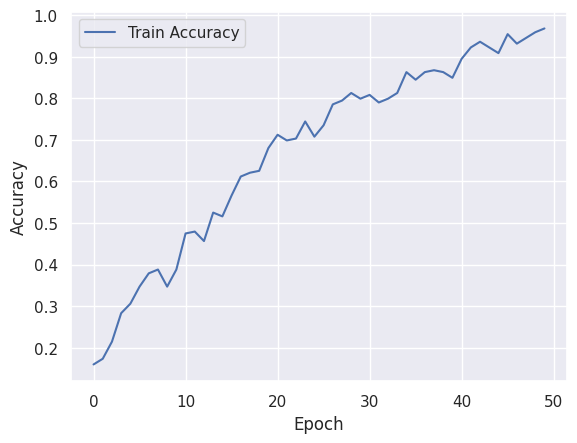

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 465ms/step
Classification Report:
              precision    recall  f1-score   support

           0      0.833     0.556     0.667         9
           1      0.400     0.500     0.444         4
           2      0.143     0.333     0.200         3
           3      0.250     0.143     0.182        14
           4      0.286     0.250     0.267        16
           5      0.294     0.455     0.357        11

    accuracy                          0.333        57
   macro avg      0.368     0.373     0.353        57
weighted avg      0.366     0.333     0.335        57



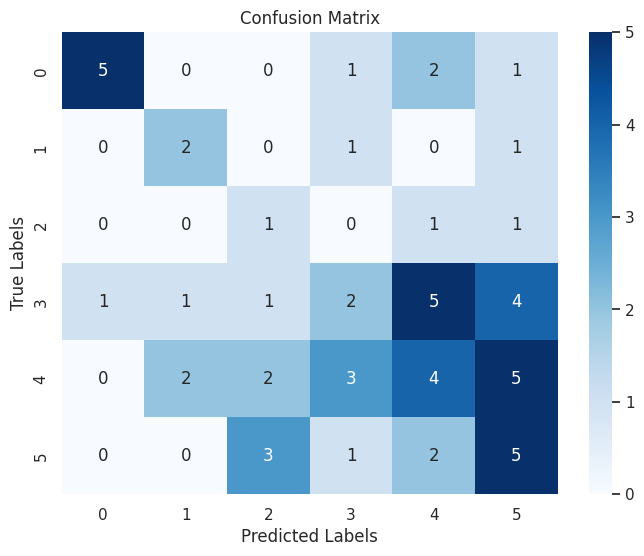

In [ ]:
y_pred = np.argmax(model.predict(X_test), axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [ ]:
print('Test set evaluation:\n_____________________________________')
print_evaluate(y_test, y_pred)

Test set evaluation:
_____________________________________
MAE: 1.3508771929824561
MSE: 3.526315789473684
RMSE: 1.877848713148555
R2 Square -0.2562500000000001
__________________________________


#LSTM Model: Multiclass, Attempt #6: Hyperparameter Tuning
This section tries out Grid Search to determine the best hyperparameters, since the previous model tuning attempts failed.

##Grid Search

In [ ]:
!pip install keras-tuner --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.8 MB/s eta 0:00:00


In [ ]:
# This cell takes a long time to run, and was killed after an hour. At the rate
# it was going it would have taken another 2 hours to run, so the optimum
# parameters found after 1 hour were used.

import keras_tuner as kt

# Will search 144 configurations
def build_model(hp):
    model = Sequential([
        LSTM(hp.Int('units', min_value=64, max_value=256, step=64),
             input_shape=(WINDOW_LENGTH, num_channels), return_sequences=True),
        Dropout(hp.Float('dropout', min_value=0.3, max_value=0.5, step=0.1)),
        LSTM(hp.Int('units_last_lstm', min_value=64, max_value=256, step=64)),
        Dropout(hp.Float('dropout_last_lstm', min_value=0.3, max_value=0.5, step=0.1)),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

tuner = kt.Hyperband(build_model, objective='val_accuracy', max_epochs=30, factor=3)
tuner.search(X_train, y_train, validation_split=0.2029, epochs=30)

Trial 90 Complete [00h 04m 51s]
val_accuracy: 0.3777777850627899

Best val_accuracy So Far: 0.4444444477558136
Total elapsed time: 01h 27m 23s


In [ ]:
# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Print the best hyperparameters
print("Best hyperparameters found:")
print(f"  LSTM units (first layer): {best_hps.get('units')}")
print(f"  Dropout (first layer): {best_hps.get('dropout')}")
print(f"  LSTM units (second layer): {best_hps.get('units_last_lstm')}")
print(f"  Dropout (second layer): {best_hps.get('dropout_last_lstm')}")

Best hyperparameters found:
  LSTM units (first layer): 64
  Dropout (first layer): 0.4
  LSTM units (second layer): 192
  Dropout (second layer): 0.3


##K-fold Cross-Validation on Best Identified Parameters

In [ ]:
model = Sequential([
    LSTM(64, input_shape=(WINDOW_LENGTH, num_channels), return_sequences=True),
    Dropout(0.4),
    LSTM(192, return_sequences=False),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
average_accuracy, fold_accuracies = cross_validate_model(
    model=model,
    X=X_shuffled,
    y=y_shuffled
)

print(f"Average Accuracy: {average_accuracy:.4f}")
print(f"Accuracies for each fold: {fold_accuracies}")

Starting Fold 1...


/usr/local/lib/python3.10/dist-packages/keras/src/callbacks/early_stopping.py:155: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.10/dist-packages/keras/src/callbacks/model_checkpoint.py:206: UserWarning: Can save best model only with val_loss available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)


Fold 1 - Test Loss: 3.2902002334594727, Test Accuracy: 0.30434781312942505
Starting Fold 2...
Fold 2 - Test Loss: 0.8545920252799988, Test Accuracy: 0.739130437374115
Starting Fold 3...
Fold 3 - Test Loss: 0.34138891100883484, Test Accuracy: 0.9130434989929199
Starting Fold 4...
Fold 4 - Test Loss: 0.20007270574569702, Test Accuracy: 0.97826087474823
Starting Fold 5...
Fold 5 - Test Loss: 0.01951751671731472, Test Accuracy: 1.0
Starting Fold 6...
Fold 6 - Test Loss: 0.0002326735557289794, Test Accuracy: 1.0

Average Test Accuracy across 6 folds: 0.8225
Average Accuracy: 0.8225
Accuracies for each fold: [0.30434781312942505, 0.739130437374115, 0.9130434989929199, 0.97826087474823, 1.0, 1.0]


##Single Run Evaluations

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 844ms/step - accuracy: 1.0000 - loss: 5.8839e-04
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 506ms/step - accuracy: 1.0000 - loss: 7.1929e-04
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 707ms/step - accuracy: 1.0000 - loss: 5.1737e-04
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 480ms/step - accuracy: 1.0000 - loss: 5.9188e-04
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 644ms/step - accuracy: 1.0000 - loss: 5.2454e-04
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 491ms/step - accuracy: 1.0000 - loss: 5.0956e-04
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 478ms/step - accuracy: 1.0000 - loss: 5.0391e-04
Epoch 8/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 747ms/step - accuracy: 1.0000 - loss: 6.1318e-04
Epoch 9/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 480ms/step - accuracy: 1.0000 - loss: 3.9708e-04
Epoch 10/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 748ms/step - accuracy: 1.0000 - loss: 5.4527e-04
Epoch 11/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 478ms/step - accuracy: 1.0000 - loss: 5.3720e-04
Epoch 12/30
7/7 ━━━━━━━━━━━━━━

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 1.0000 - loss: 1.6125e-04
Test Loss: 0.00015972772962413728, Test Accuracy: 1.0


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 407ms/step
Classification Report:
              precision    recall  f1-score   support

           0      1.000     1.000     1.000         9
           1      1.000     1.000     1.000         4
           2      1.000     1.000     1.000         3
           3      1.000     1.000     1.000        14
           4      1.000     1.000     1.000        16
           5      1.000     1.000     1.000        11

    accuracy                          1.000        57
   macro avg      1.000     1.000     1.000        57
weighted avg      1.000     1.000     1.000        57



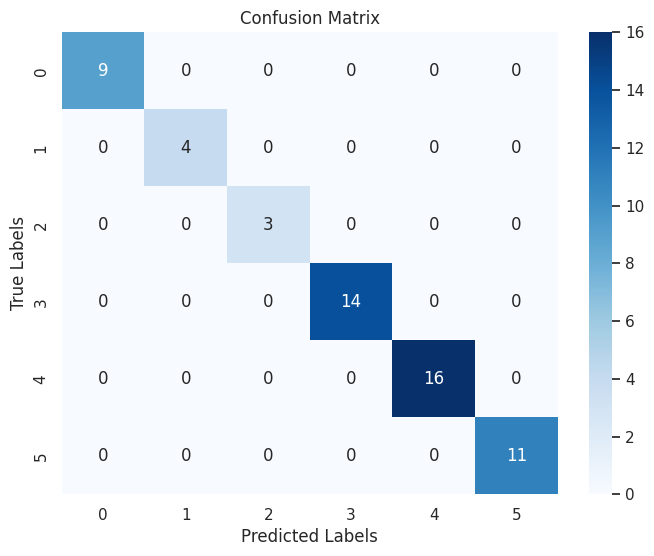

In [ ]:
y_pred = np.argmax(model.predict(X_test), axis=1)

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

#Conclusion
LSTM can classify rest versus movement very well, as demonstrated by the high cross-validation score of 99%. After hyperparameter tuning, it distinguishes between the different movements fairly well, with an average cross-validation accuracy of 0.84. Also, the accuracy improved with each fold, and was 100% for folds 4 through 6. The data obtained is from an old, outdated EEG device, and using a more modern one with more channels may result in better results. More data would also be helpful, as there are only 276 observations across 6 classes, so there are only 46 observations per class.

#References
[1] A. Raj, “Innovative Rehabilitation Approach for Upper Limb Neurologic Conditions Using Mixed-Reality Simulation and EEG/EMG Biofeedback,” Master of Science, Computer Science and Software Engineering, University of Washington - Bothell, Bothell, WA, 2024.